# Credit Scoring — Model untuk Aplikasi

Notebook ini melatih model credit scoring dari raw `application_train.csv`
dan menyimpan semua komponen yang dibutuhkan aplikasi:
- `model_artifacts.pkl` → model + threshold + encoder + median + kolom

User aplikasi hanya perlu mengisi **15 field**, sisanya dihitung otomatis.

---

## Alur

```
[1] Setup & Load Data
[2] Preprocessing
[3] Feature Engineering
[4] Training & Evaluasi
[5] Simpan Artifacts
[6] Simulasi Prediksi (seperti input dari form)
```

---
# [1] SETUP & LOAD DATA

In [1]:
%pip install scikit-learn xgboost lightgbm catboost pandas matplotlib seaborn joblib --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, time, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print('Library siap.')

Library siap.


In [3]:
train_raw = pd.read_csv('home-credit-default-risk/application_train.csv')
test_raw  = pd.read_csv('home-credit-default-risk/application_test.csv')

print(f'Train : {train_raw.shape[0]:,} baris x {train_raw.shape[1]} kolom')
print(f'Test  : {test_raw.shape[0]:,} baris x {test_raw.shape[1]} kolom')
print(f'Target: {train_raw["TARGET"].value_counts()[1]:,} gagal bayar '
      f'({train_raw["TARGET"].mean()*100:.1f}%)')

Train : 307,511 baris x 122 kolom
Test  : 48,744 baris x 121 kolom
Target: 24,825 gagal bayar (8.1%)


---
# [2] PREPROCESSING

| Masalah | Penanganan |
|---|---|
| Kolom missing > 50% | Di-drop |
| Missing numerik ≤ 50% | Isi median |
| Missing kategorikal | Isi 'Unknown' |
| `DAYS_EMPLOYED = 365243` | Ganti NaN + buat flag |
| Outlier income | Cap 99th percentile |
| Kolom kategorikal | Label Encoding |

In [4]:
def preprocess(df, is_train=True, artifacts=None):
    df = df.copy()
    df.drop(columns=['SK_ID_CURR'], errors='ignore', inplace=True)

    # Anomali DAYS_EMPLOYED: 365243 = tidak bekerja / pensiunan
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED']      = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    if is_train:
        artifacts = {}

        # Drop kolom missing > 50%
        miss_pct = df.isnull().mean()
        drop_cols = miss_pct[miss_pct > 0.5].index.tolist()
        for c in ['TARGET']:
            if c in drop_cols:
                drop_cols.remove(c)
        artifacts['drop_cols'] = drop_cols

        # Cap outlier income
        artifacts['income_cap'] = df['AMT_INCOME_TOTAL'].quantile(0.99)

    df['AMT_INCOME_TOTAL'] = df['AMT_INCOME_TOTAL'].clip(upper=artifacts['income_cap'])
    df.drop(columns=[c for c in artifacts['drop_cols'] if c in df.columns], inplace=True)

    num_cols = df.select_dtypes(include='number').columns.tolist()
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    if 'TARGET' in num_cols:
        num_cols.remove('TARGET')

    if is_train:
        artifacts['medians']  = df[num_cols].median()
        artifacts['encoders'] = {}

    # Isi missing
    df[num_cols] = df[num_cols].fillna(artifacts['medians'])
    df[cat_cols] = df[cat_cols].fillna('Unknown')

    # Label encoding
    for col in cat_cols:
        if is_train:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            artifacts['encoders'][col] = le
        else:
            le = artifacts['encoders'].get(col)
            if le:
                known = set(le.classes_)
                df[col] = df[col].astype(str).apply(
                    lambda x: x if x in known else le.classes_[0])
                df[col] = le.transform(df[col])

    if is_train:
        return df, artifacts
    return df

print('Fungsi preprocess siap.')

Fungsi preprocess siap.


In [5]:
train_clean, artifacts = preprocess(train_raw, is_train=True)
test_clean = preprocess(test_raw, is_train=False, artifacts=artifacts)

print(f'Train setelah preprocessing : {train_clean.shape}')
print(f'Test  setelah preprocessing : {test_clean.shape}')
print(f'Kolom di-drop (missing>50%) : {len(artifacts["drop_cols"])}')
print(f'Missing tersisa             : {train_clean.isnull().sum().sum()}')

Train setelah preprocessing : (307511, 81)
Test  setelah preprocessing : (48744, 80)
Kolom di-drop (missing>50%) : 41
Missing tersisa             : 0


---
# [3] FEATURE ENGINEERING

Membuat 13 fitur baru dari kombinasi fitur yang ada.

In [6]:
def feature_engineering(df):
    df = df.copy()

    # Rasio keuangan
    df['CREDIT_INCOME_RATIO']  = df['AMT_CREDIT']  / (df['AMT_INCOME_TOTAL'] + 1)
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['CREDIT_GOODS_RATIO']   = df['AMT_CREDIT']  / (df['AMT_GOODS_PRICE']  + 1)
    df['ANNUITY_CREDIT_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_CREDIT']       + 1)

    # Usia & masa kerja
    df['AGE_YEARS']          = np.abs(df['DAYS_BIRTH'])    / 365
    df['EMPLOYED_YEARS']     = np.abs(df['DAYS_EMPLOYED']) / 365
    df['EMPLOYED_AGE_RATIO'] = df['EMPLOYED_YEARS'] / (df['AGE_YEARS'] + 1)

    # Gabungan EXT_SOURCE (fitur paling prediktif)
    ext = [c for c in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3'] if c in df.columns]
    if ext:
        df['EXT_SOURCE_MEAN'] = df[ext].mean(axis=1)
        df['EXT_SOURCE_MIN']  = df[ext].min(axis=1)
        df['EXT_SOURCE_PROD'] = df[ext].prod(axis=1)

    # Kelengkapan & kontak
    doc_cols     = [c for c in df.columns if 'FLAG_DOCUMENT' in c]
    contact_cols = [c for c in df.columns if c in [
        'FLAG_MOBIL','FLAG_EMP_PHONE','FLAG_WORK_PHONE',
        'FLAG_CONT_MOBILE','FLAG_PHONE','FLAG_EMAIL']]
    df['TOTAL_DOCS_SUBMITTED'] = df[doc_cols].sum(axis=1)
    df['TOTAL_CONTACT_FLAGS']  = df[contact_cols].sum(axis=1)

    return df

train_fe = feature_engineering(train_clean)
test_fe  = feature_engineering(test_clean)

new_feats = [c for c in train_fe.columns if c not in train_clean.columns]
print(f'Fitur baru : {len(new_feats)} → {new_feats}')
print(f'Total fitur: {train_fe.shape[1] - 1}')

Fitur baru : 12 → ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'ANNUITY_CREDIT_RATIO', 'AGE_YEARS', 'EMPLOYED_YEARS', 'EMPLOYED_AGE_RATIO', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_PROD', 'TOTAL_DOCS_SUBMITTED', 'TOTAL_CONTACT_FLAGS']
Total fitur: 92


---
# [4] TRAINING & EVALUASI

In [7]:
X = train_fe.drop(columns=['TARGET'])
y = train_fe['TARGET']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
sw        = compute_sample_weight('balanced', y_train)

# Simpan kolom untuk kebutuhan aplikasi
artifacts['feature_cols'] = list(X_train.columns)

print(f'Fitur      : {X_train.shape[1]}')
print(f'Train      : {X_train.shape[0]:,}')
print(f'Validation : {X_val.shape[0]:,}')
print(f'scale_pos  : {scale_pos:.2f}')

Fitur      : 92
Train      : 246,008
Validation : 61,503
scale_pos  : 11.39


In [8]:
models = {
    'XGBoost': XGBClassifier(
        n_estimators=300, scale_pos_weight=scale_pos,
        learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='auc', verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, class_weight='balanced',
        learning_rate=0.05, max_depth=5, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, auto_class_weights='Balanced',
        learning_rate=0.05, depth=5,
        random_state=42, verbose=0
    ),
}

trained = {}
times   = {}
for nama, model in models.items():
    print(f'Training {nama}...', end=' ')
    t = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t
    trained[nama] = model
    times[nama]   = elapsed
    print(f'selesai ({elapsed:.1f}s)')

Training XGBoost... selesai (18.7s)
Training LightGBM... selesai (5.1s)
Training CatBoost... selesai (9.5s)


In [9]:
# Evaluasi + threshold optimal
hasil      = []
thresholds = {}

for nama, model in trained.items():
    y_prob = model.predict_proba(X_val)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_val, y_prob)
    f1_arr   = np.where((prec+rec)==0, 0, 2*prec*rec/(prec+rec))
    best_thr = thresh[np.argmax(f1_arr[:-1])]
    thresholds[nama] = best_thr

    y_pred = (y_prob >= best_thr).astype(int)
    hasil.append({
        'Model'    : nama,
        'AUC-ROC'  : roc_auc_score(y_val, y_prob),
        'Gini'     : 2 * roc_auc_score(y_val, y_prob) - 1,
        'F1'       : f1_score(y_val, y_pred, zero_division=0),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall'   : recall_score(y_val, y_pred, zero_division=0),
        'Threshold': best_thr,
        'Waktu'    : times[nama],
    })

df_h = pd.DataFrame(hasil).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
df_h.index += 1

print('=' * 85)
print(f"{'HASIL EVALUASI (threshold optimal)':^85}")
print('=' * 85)
for _, r in df_h.iterrows():
    print(f"  {r['Model']:<12} AUC={r['AUC-ROC']:.4f}  Gini={r['Gini']:.4f}  "
          f"F1={r['F1']:.4f}  Precision={r['Precision']:.4f}  "
          f"Recall={r['Recall']:.4f}  Thr={r['Threshold']:.3f}  ({r['Waktu']:.1f}s)")
print('=' * 85)

                         HASIL EVALUASI (threshold optimal)                          
  XGBoost      AUC=0.7656  Gini=0.5312  F1=0.3157  Precision=0.2686  Recall=0.3827  Thr=0.687  (18.7s)
  LightGBM     AUC=0.7642  Gini=0.5284  F1=0.3147  Precision=0.2552  Recall=0.4103  Thr=0.668  (5.1s)
  CatBoost     AUC=0.7610  Gini=0.5220  F1=0.3090  Precision=0.2518  Recall=0.3996  Thr=0.673  (9.5s)


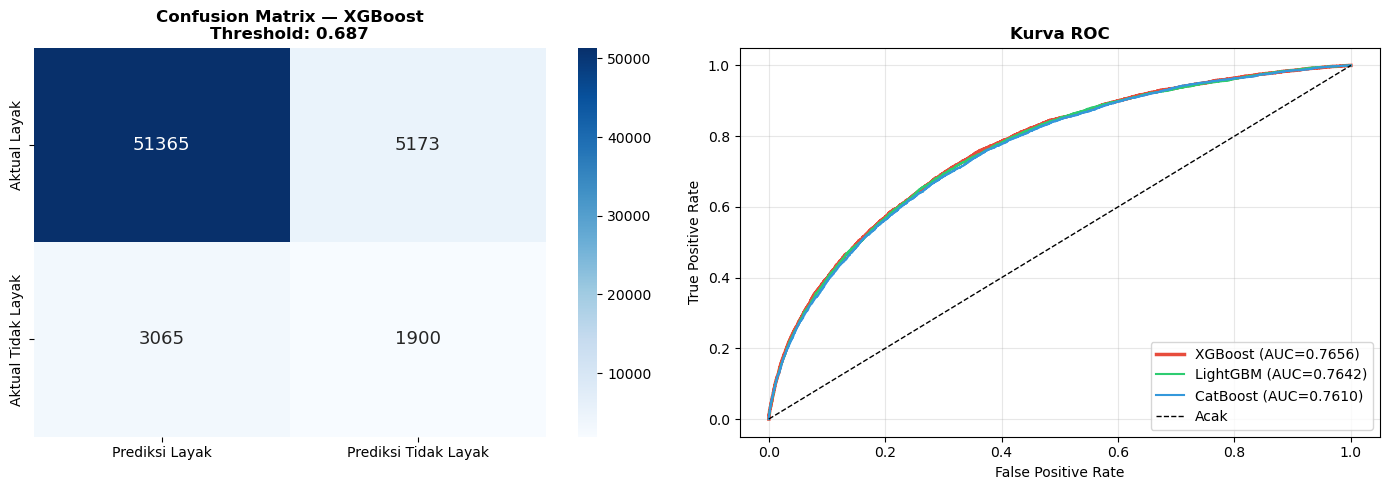

                 precision    recall  f1-score   support

      Layak (0)       0.94      0.91      0.93     56538
Tidak Layak (1)       0.27      0.38      0.32      4965

       accuracy                           0.87     61503
      macro avg       0.61      0.65      0.62     61503
   weighted avg       0.89      0.87      0.88     61503

AUC-ROC : 0.7656
Gini    : 0.5312


In [10]:
# Plot ROC + Confusion Matrix model terbaik
nama_best  = df_h.iloc[0]['Model']
model_best = trained[nama_best]
thr_best   = thresholds[nama_best]

y_prob_best = model_best.predict_proba(X_val)[:, 1]
y_pred_best = (y_prob_best >= thr_best).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Prediksi Layak','Prediksi Tidak Layak'],
            yticklabels=['Aktual Layak','Aktual Tidak Layak'],
            annot_kws={'size':13})
axes[0].set_title(f'Confusion Matrix — {nama_best}\nThreshold: {thr_best:.3f}', fontweight='bold')

# ROC semua model
warna = ['#e74c3c','#2ecc71','#3498db']
for idx, (nama, model) in enumerate(trained.items()):
    y_p  = model.predict_proba(X_val)[:, 1]
    auc  = roc_auc_score(y_val, y_p)
    fpr, tpr, _ = roc_curve(y_val, y_p)
    lw   = 2.5 if nama == nama_best else 1.5
    axes[1].plot(fpr, tpr, color=warna[idx], lw=lw,
                 label=f'{nama} (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1],'k--',lw=1,label='Acak')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Kurva ROC', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(classification_report(y_val, y_pred_best,
      target_names=['Layak (0)','Tidak Layak (1)']))
print(f'AUC-ROC : {roc_auc_score(y_val, y_prob_best):.4f}')
print(f'Gini    : {2*roc_auc_score(y_val, y_prob_best)-1:.4f}')

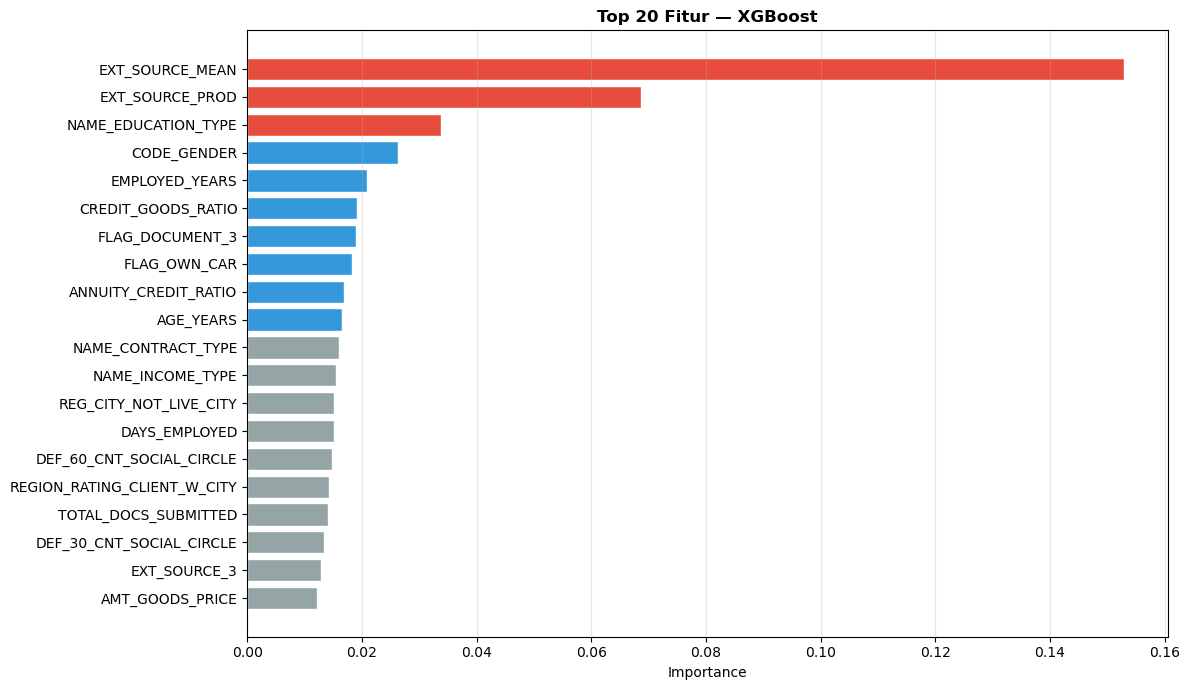

Top 10 fitur:
   1. EXT_SOURCE_MEAN                     0.152978
   2. EXT_SOURCE_PROD                     0.068630
   3. NAME_EDUCATION_TYPE                 0.033780
   4. CODE_GENDER                         0.026221
   5. EMPLOYED_YEARS                      0.020881
   6. CREDIT_GOODS_RATIO                  0.019171
   7. FLAG_DOCUMENT_3                     0.018933
   8. FLAG_OWN_CAR                        0.018293
   9. ANNUITY_CREDIT_RATIO                0.016917
  10. AGE_YEARS                           0.016457


In [11]:
# Feature importance
imp = model_best.feature_importances_
fi  = pd.DataFrame({'Fitur': X_train.columns, 'Importance': imp})
fi  = fi.sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if i < 3 else '#3498db' if i < 10 else '#95a5a6'
          for i in range(len(fi))]
ax.barh(fi['Fitur'][::-1], fi['Importance'][::-1], color=colors[::-1], edgecolor='white')
ax.set_title(f'Top 20 Fitur — {nama_best}', fontweight='bold')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 10 fitur:')
for i, (_, r) in enumerate(fi.head(10).iterrows()):
    print(f'  {i+1:>2}. {r["Fitur"]:<35} {r["Importance"]:.6f}')

---
# [5] SIMPAN ARTIFACTS

Simpan semua komponen yang dibutuhkan aplikasi.

In [12]:
os.makedirs('home-credit-default-risk/InfiniteLearning', exist_ok=True)

artifacts['model']      = model_best
artifacts['threshold']  = thr_best
artifacts['model_name'] = nama_best

save_path = 'home-credit-default-risk/InfiniteLearning/model_artifacts.pkl'
joblib.dump(artifacts, save_path)

print(f'Artifacts tersimpan  : {save_path}')
print(f'Model terbaik        : {nama_best}')
print(f'Threshold optimal    : {thr_best:.4f}')
print(f'Total fitur          : {len(artifacts["feature_cols"])}')
print(f'Kolom yang di-drop   : {len(artifacts["drop_cols"])}')
print(f'Encoder tersimpan    : {len(artifacts["encoders"])} kolom')
print()
print('Komponen artifacts:')
for k in artifacts.keys():
    if k not in ['model']:
        print(f'  - {k}')

Artifacts tersimpan  : home-credit-default-risk/InfiniteLearning/model_artifacts.pkl
Model terbaik        : XGBoost
Threshold optimal    : 0.6867
Total fitur          : 92
Kolom yang di-drop   : 41
Encoder tersimpan    : 13 kolom

Komponen artifacts:
  - drop_cols
  - income_cap
  - medians
  - encoders
  - feature_cols
  - threshold
  - model_name


---
# [6] SIMULASI PREDIKSI

Simulasi seperti user mengisi form aplikasi.
Hanya **15 field** yang diisi user, sisanya dihitung otomatis oleh sistem.

In [13]:
# ── Input dari user (simulasi form) ────────────────────────────────────
user_input = {
    # Field yang diisi user
    'NAME_CONTRACT_TYPE'        : 'Cash loans',        # jenis pinjaman
    'CODE_GENDER'               : 'M',                 # jenis kelamin
    'FLAG_OWN_CAR'              : 'N',                 # punya mobil?
    'FLAG_OWN_REALTY'           : 'Y',                 # punya properti?
    'CNT_CHILDREN'              : 0,                   # jumlah anak
    'AMT_INCOME_TOTAL'          : 180000,              # penghasilan/tahun
    'AMT_CREDIT'                : 450000,              # jumlah kredit
    'AMT_GOODS_PRICE'           : 450000,              # harga barang
    'NAME_INCOME_TYPE'          : 'Working',           # jenis pekerjaan
    'NAME_EDUCATION_TYPE'       : 'Higher education',  # pendidikan
    'NAME_FAMILY_STATUS'        : 'Married',           # status keluarga
    'NAME_HOUSING_TYPE'         : 'House / apartment', # jenis hunian
    'OCCUPATION_TYPE'           : 'Managers',          # jabatan
    'ORGANIZATION_TYPE'         : 'Business Entity Type 3', # jenis organisasi
    'CNT_FAM_MEMBERS'           : 2.0,                 # jumlah anggota keluarga

    # Dihitung otomatis dari tanggal lahir & tanggal kerja
    'DAYS_BIRTH'                : -35 * 365,           # usia 35 tahun
    'DAYS_EMPLOYED'             : -5 * 365,            # sudah kerja 5 tahun
}

# ── Field lain diisi dengan nilai median (default sistem) ────────────────
defaults = {
    'AMT_ANNUITY'               : artifacts['medians'].get('AMT_ANNUITY', 26000),
    'NAME_TYPE_SUITE'           : 'Unaccompanied',
    'DAYS_REGISTRATION'         : -4504.0,
    'DAYS_ID_PUBLISH'           : -3254.0,
    'DAYS_LAST_PHONE_CHANGE'    : -757.0,
    'FLAG_MOBIL'                : 1,
    'FLAG_EMP_PHONE'            : 1,
    'FLAG_WORK_PHONE'           : 0,
    'FLAG_CONT_MOBILE'          : 1,
    'FLAG_PHONE'                : 0,
    'FLAG_EMAIL'                : 0,
    'REGION_RATING_CLIENT'      : 2,
    'REGION_RATING_CLIENT_W_CITY': 2,
    'REGION_POPULATION_RELATIVE': 0.0188,
    'REG_CITY_NOT_LIVE_CITY'    : 0,
    'REG_CITY_NOT_WORK_CITY'    : 0,
    'REG_REGION_NOT_WORK_REGION': 0,
    'LIVE_CITY_NOT_WORK_CITY'   : 0,
    'WEEKDAY_APPR_PROCESS_START': 'TUESDAY',
    'HOUR_APPR_PROCESS_START'   : 10,
    'EXT_SOURCE_2'              : 0.5660,
    'EXT_SOURCE_3'              : 0.5353,
}
user_input.update(defaults)

print('Input user siap.')

Input user siap.


In [14]:
def predict_single(user_input, artifacts):
    df = pd.DataFrame([user_input])

    # Anomali DAYS_EMPLOYED
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED']      = df['DAYS_EMPLOYED'].replace(365243, np.nan)

    # Cap income
    df['AMT_INCOME_TOTAL'] = df['AMT_INCOME_TOTAL'].clip(upper=artifacts['income_cap'])

    # Isi kolom yang tidak ada dengan median
    for col, val in artifacts['medians'].items():
        if col not in df.columns:
            df[col] = val

    # Isi missing
    num_cols = df.select_dtypes(include='number').columns.tolist()
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    df[num_cols] = df[num_cols].fillna(artifacts['medians'].reindex(num_cols))
    df[cat_cols] = df[cat_cols].fillna('Unknown')

    # Label encoding
    for col, le in artifacts['encoders'].items():
        if col in df.columns:
            known = set(le.classes_)
            df[col] = df[col].astype(str).apply(
                lambda x: x if x in known else le.classes_[0])
            df[col] = le.transform(df[col])

    # Feature engineering
    df['CREDIT_INCOME_RATIO']  = df['AMT_CREDIT']  / (df['AMT_INCOME_TOTAL'] + 1)
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['CREDIT_GOODS_RATIO']   = df['AMT_CREDIT']  / (df['AMT_GOODS_PRICE']  + 1)
    df['ANNUITY_CREDIT_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_CREDIT']       + 1)
    df['AGE_YEARS']            = np.abs(df['DAYS_BIRTH'])    / 365
    df['EMPLOYED_YEARS']       = np.abs(df['DAYS_EMPLOYED']) / 365
    df['EMPLOYED_AGE_RATIO']   = df['EMPLOYED_YEARS'] / (df['AGE_YEARS'] + 1)

    ext = [c for c in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3'] if c in df.columns]
    if ext:
        df['EXT_SOURCE_MEAN'] = df[ext].mean(axis=1)
        df['EXT_SOURCE_MIN']  = df[ext].min(axis=1)
        df['EXT_SOURCE_PROD'] = df[ext].prod(axis=1)

    doc_cols     = [c for c in artifacts['feature_cols'] if 'FLAG_DOCUMENT' in c]
    contact_cols = [c for c in artifacts['feature_cols'] if c in [
        'FLAG_MOBIL','FLAG_EMP_PHONE','FLAG_WORK_PHONE',
        'FLAG_CONT_MOBILE','FLAG_PHONE','FLAG_EMAIL']]
    if doc_cols:
        df['TOTAL_DOCS_SUBMITTED'] = df[[c for c in doc_cols if c in df.columns]].sum(axis=1)
    if contact_cols:
        df['TOTAL_CONTACT_FLAGS']  = df[[c for c in contact_cols if c in df.columns]].sum(axis=1)

    # Align ke kolom training
    df = df.reindex(columns=artifacts['feature_cols'], fill_value=0)

    # Prediksi
    model = artifacts['model']
    thr   = artifacts['threshold']
    prob  = model.predict_proba(df)[0, 1]
    label = int(prob >= thr)

    if prob <= 0.30:
        risiko = 'RENDAH'
        warna  = '🟢'
    elif prob <= 0.50:
        risiko = 'SEDANG'
        warna  = '🟡'
    else:
        risiko = 'TINGGI'
        warna  = '🔴'

    return {
        'probabilitas' : round(prob, 4),
        'persen'       : f'{prob*100:.2f}%',
        'prediksi'     : label,
        'status'       : 'TIDAK LAYAK' if label == 1 else 'LAYAK',
        'risiko'       : risiko,
        'skor_kredit'  : int(850 - prob * 550),
        'warna'        : warna,
    }

hasil = predict_single(user_input, artifacts)

print('=' * 50)
print(f"  HASIL CREDIT SCORING")
print('=' * 50)
print(f"  Status          : {hasil['warna']} {hasil['status']}")
print(f"  Skor Kredit     : {hasil['skor_kredit']} / 850")
print(f"  Probabilitas    : {hasil['persen']}")
print(f"  Kategori Risiko : {hasil['risiko']}")
print('=' * 50)
print()
print('Interpretasi skor kredit:')
print('  750 - 850 : Sangat Baik  → Layak, bunga rendah')
print('  650 - 749 : Baik         → Layak')
print('  550 - 649 : Cukup        → Perlu review')
print('  300 - 549 : Buruk        → Tidak Layak')

  HASIL CREDIT SCORING
  Status          : 🟡 LAYAK
  Skor Kredit     : 619 / 850
  Probabilitas    : 41.92%
  Kategori Risiko : SEDANG

Interpretasi skor kredit:
  750 - 850 : Sangat Baik  → Layak, bunga rendah
  650 - 749 : Baik         → Layak
  550 - 649 : Cukup        → Perlu review
  300 - 549 : Buruk        → Tidak Layak


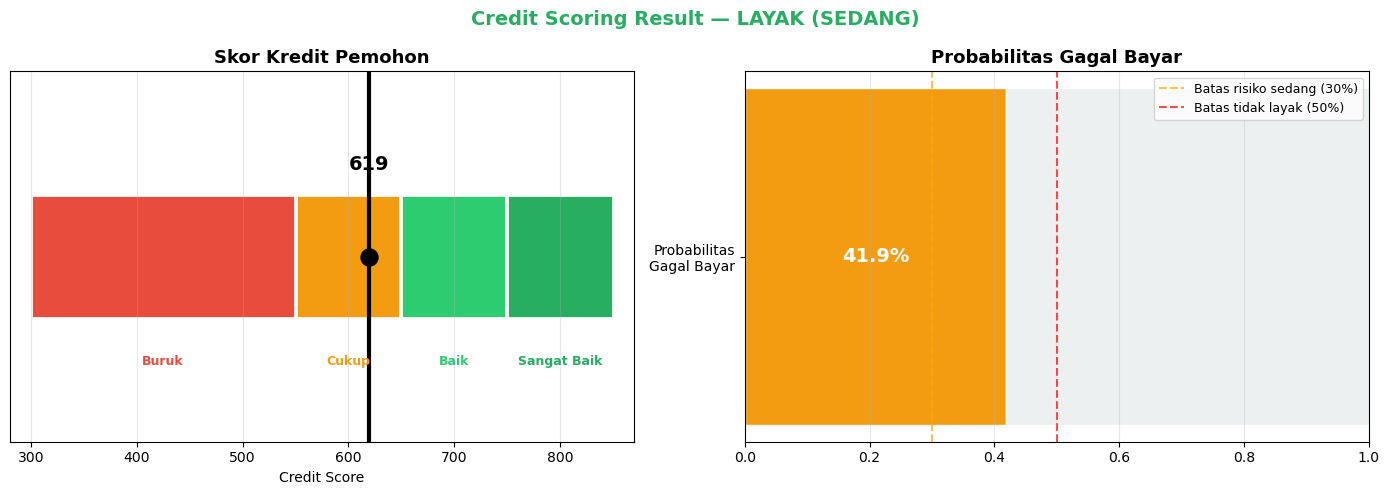

In [15]:
# Visualisasi hasil
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gauge skor kredit
ax1 = axes[0]
skor = hasil['skor_kredit']
segments = [(300, 549, '#e74c3c', 'Buruk'),
            (550, 649, '#f39c12', 'Cukup'),
            (650, 749, '#2ecc71', 'Baik'),
            (750, 850, '#27ae60', 'Sangat Baik')]
for start, end, color, label in segments:
    ax1.barh(0, end-start, left=start, height=0.4, color=color,
             edgecolor='white', linewidth=2)
    ax1.text((start+end)/2, -0.35, label, ha='center', fontsize=9, color=color, fontweight='bold')
ax1.axvline(skor, color='black', linewidth=3, label=f'Skor: {skor}')
ax1.scatter([skor], [0], color='black', s=150, zorder=5)
ax1.text(skor, 0.28, f'{skor}', ha='center', fontsize=14, fontweight='bold')
ax1.set_xlim(280, 870)
ax1.set_ylim(-0.6, 0.6)
ax1.set_yticks([])
ax1.set_xlabel('Credit Score')
ax1.set_title('Skor Kredit Pemohon', fontweight='bold', fontsize=13)
ax1.grid(axis='x', alpha=0.3)

# Probabilitas
ax2 = axes[1]
prob  = hasil['probabilitas']
warna = '#e74c3c' if prob > 0.5 else '#f39c12' if prob > 0.3 else '#2ecc71'
ax2.barh(['Probabilitas\nGagal Bayar'], [prob], color=warna,
         edgecolor='white', height=0.4)
ax2.barh(['Probabilitas\nGagal Bayar'], [1-prob], left=[prob],
         color='#ecf0f1', edgecolor='white', height=0.4)
ax2.axvline(0.3,  color='orange', linestyle='--', alpha=0.7, label='Batas risiko sedang (30%)')
ax2.axvline(0.5,  color='red',    linestyle='--', alpha=0.7, label='Batas tidak layak (50%)')
ax2.text(prob/2, 0, f"{prob*100:.1f}%", ha='center', va='center',
         fontsize=14, fontweight='bold', color='white')
ax2.set_xlim(0, 1)
ax2.set_title('Probabilitas Gagal Bayar', fontweight='bold', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle(f"Credit Scoring Result — {hasil['status']} ({hasil['risiko']})",
             fontsize=14, fontweight='bold',
             color='#e74c3c' if hasil['prediksi']==1 else '#27ae60')
plt.tight_layout()
plt.show()

---
## Ringkasan

| Komponen | Detail |
|---|---|
| **Input user** | 15 field (demografi, keuangan, pekerjaan) |
| **Dihitung otomatis** | Semua rasio, usia, masa kerja, fitur engineering |
| **Output** | Status, Skor Kredit (300–850), Probabilitas, Kategori Risiko |
| **Artifacts** | `model_artifacts.pkl` (model + threshold + encoder + median + kolom) |

### Cara pakai di aplikasi lain

```python
import joblib, numpy as np, pandas as pd

# Load artifacts
artifacts = joblib.load('home-credit-default-risk/InfiniteLearning/model_artifacts.pkl')

# Jalankan fungsi predict_single dengan input user
hasil = predict_single(user_input, artifacts)
print(hasil['status'])       # LAYAK / TIDAK LAYAK
print(hasil['skor_kredit'])  # 300 - 850
print(hasil['persen'])       # persentase gagal bayar
```

### Interpretasi Skor Kredit

| Skor | Kategori | Keputusan |
|---|---|---|
| 750 – 850 | Sangat Baik | Layak, bunga rendah |
| 650 – 749 | Baik | Layak |
| 550 – 649 | Cukup | Perlu review manual |
| 300 – 549 | Buruk | Tidak Layak |